In [2]:
import numpy as np
import matplotlib.pyplot as plt
import joblib

from tensorflow.keras.models import Model

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    Add,
    LSTM,
    GlobalAveragePooling1D
)

from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [3]:
X_train = np.load(
    "C:\\Users\\ASUS\\Desktop\\Narmada Project\\Data\\Processed\\sequences\\X_train.npy"
)

y_train = np.load(
    "C:\\Users\\ASUS\\Desktop\\Narmada Project\\Data\\Processed\\sequences\\y_train.npy"
)

X_val = np.load(
    "C:\\Users\\ASUS\\Desktop\\Narmada Project\\Data\\Processed\\sequences\\X_val.npy"
)

y_val = np.load(
    "C:\\Users\\ASUS\\Desktop\\Narmada Project\\Data\\Processed\\sequences\\y_val.npy"
)

X_test = np.load(
    "C:\\Users\\ASUS\\Desktop\\Narmada Project\\Data\\Processed\\sequences\\X_test.npy"
)

y_test = np.load(
    "C:\\Users\\ASUS\\Desktop\\Narmada Project\\Data\\Processed\\sequences\\y_test.npy"
)


In [4]:
y_train_flow = y_train[:, 1]
y_val_flow   = y_val[:, 1]
y_test_flow  = y_test[:, 1]

In [5]:
inputs = Input(shape=(30,16))

In [6]:
attention_output = MultiHeadAttention(

    num_heads=2,

    key_dim=16

)(inputs, inputs)

# Residual Connection

x = Add()([inputs, attention_output])


In [7]:
x = LayerNormalization()(x)

In [8]:
ffn = Dense(64, activation='relu')(x)

ffn = Dense(16)(ffn)

In [9]:
x = Add()([x, ffn])

In [10]:
x = LayerNormalization()(x)

In [11]:
x = LSTM(64)(x)

In [12]:
x = Dropout(0.2)(x)

In [13]:
x = Dense(32, activation='relu')(x)

outputs = Dense(1)(x)   

In [14]:
model = Model(inputs, outputs)

In [15]:
model.compile(

    optimizer='adam',

    loss='mse',

    metrics=['mae']

)

In [16]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 16)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 16)    │      2,160 │ input_layer[0][0… │
│ (MultiHeadAttentio… │                   │            │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 16)    │          0 │ input_layer[0][0… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 16)    │         32 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 64)    │      1,088 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 16)    │      1,040 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 16)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 16)    │         32 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     20,736 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,201 (106.25 KB)

 Trainable params: 27,201 (106.25 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=8,

    restore_best_weights=True

)

In [18]:
history = model.fit(

    X_train,
    y_train_flow,

    validation_data=(X_val, y_val_flow),

    epochs=50,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0022 - mae: 0.0185 - val_loss: 3.0848e-05 - val_mae: 0.0035
Epoch 2/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 6.1534e-04 - mae: 0.0085 - val_loss: 1.4758e-05 - val_mae: 0.0025
Epoch 3/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 4.9906e-04 - mae: 0.0074 - val_loss: 2.1316e-05 - val_mae: 0.0032
Epoch 4/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 4.1659e-04 - mae: 0.0067 - val_loss: 3.2927e-05 - val_mae: 0.0050
Epoch 5/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 4.1048e-04 - mae: 0.0066 - val_loss: 1.0625e-05 - val_mae: 0.0010
Epoch 6/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 3.4672e-04 - mae: 0.0064 - val_loss: 1.9944e-05 - val_mae: 0.0035
Epoch 7/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 3.2646e-04 - mae: 0.0060 - val_loss: 1.3053e-05 - val_mae: 0.0023
Epoch 8/50
710/710 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 3.5812e-04 - mae: 0.0067 - val_loss: 5.6907e-05 - val_mae:

In [19]:
y_pred = model.predict(X_test)

y_pred = y_pred.flatten()

152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


In [20]:
scaler = joblib.load(
    "C:\\Users\\ASUS\\Desktop\\Narmada Project\\Data\\Processed\\Scalars\\scaler.pkl"
)

In [21]:
dummy_pred = np.zeros((len(y_pred), 16))
dummy_true = np.zeros((len(y_test_flow), 16))

# flow = index 15

dummy_pred[:, 15] = y_pred
dummy_true[:, 15] = y_test_flow

inv_pred = scaler.inverse_transform(dummy_pred)[:, 15]
inv_true = scaler.inverse_transform(dummy_true)[:, 15]

In [22]:
rmse = np.sqrt(mean_squared_error(inv_true, inv_pred))

mae = mean_absolute_error(inv_true, inv_pred)

r2 = r2_score(inv_true, inv_pred)

print("\nTRANSFORMER-LSTM FLOW METRICS")

print("RMSE:", rmse)

print("MAE :", mae)

print("R2  :", r2)


TRANSFORMER-LSTM FLOW METRICS
RMSE: 220.89289701881282
MAE : 49.819130725551666
R2  : 0.05980999343061211


In [23]:
print("\nFlow Variance:", np.var(inv_true))


Flow Variance: 51897.67133497262


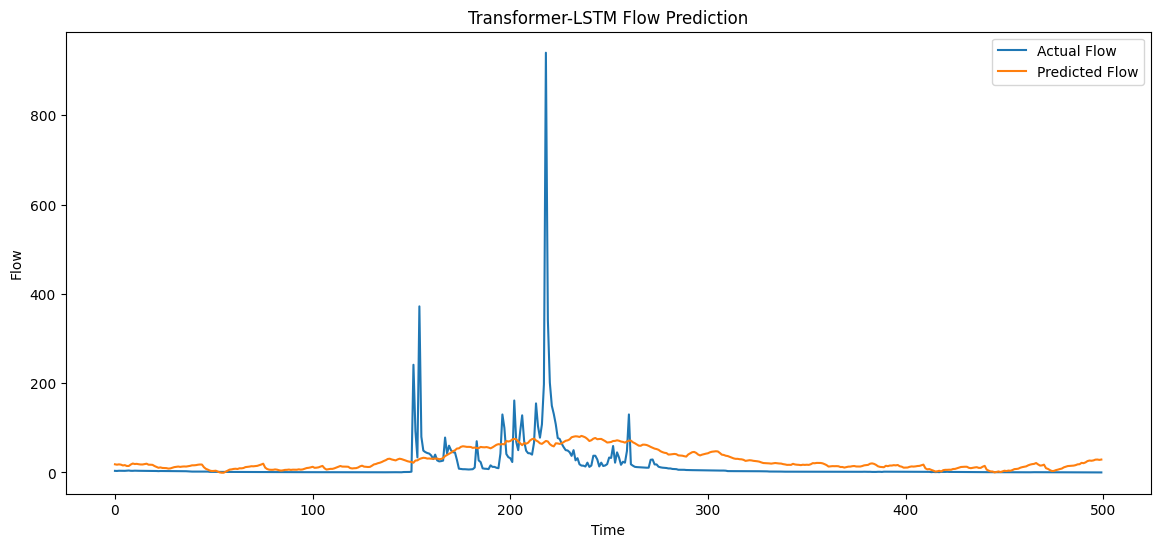

In [24]:
plt.figure(figsize=(14,6))

plt.plot(
    inv_true[:500],
    label='Actual Flow'
)

plt.plot(
    inv_pred[:500],
    label='Predicted Flow'
)

plt.title("Transformer-LSTM Flow Prediction")

plt.xlabel("Time")

plt.ylabel("Flow")

plt.legend()

plt.show()

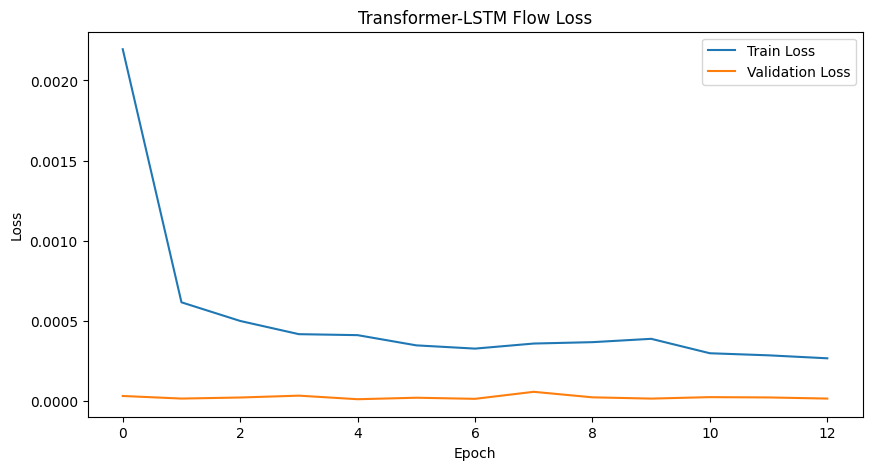

In [25]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title("Transformer-LSTM Flow Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()